## HW 1

Как меняется ожидаемая гетерозиготность в модели Wright-Fisher со временем?
1) Напишите симулятор модели WF для N = 50 диплоидов, p0 = 0.2, T = 200.
2) Визуализируйте траектории частот pt для R = 30 репликаций.
3) Визуализируйте ожидаемую гетерозиготность. Что вы наблюдаете?
4) Выполняется ли в Ваших симуляциях теорема о поглощении?
5) Просимулируйте эффект бутылочного горлышка (N = 50 -> N = 10 ) в период
T = 100,…,125

In [ ]:
import numpy as np
import matplotlib.pyplot as pyplot

In [88]:
def binomial(n, p):
    return np.random.binomial(n, p)

def wright_fisher_modeling(n, p0, times=100):
    p_curr = p0
    # аллелей в 2 раза больше
    N = 2 * n
    result_seq = np.array(p0)
    for _ in range(times):
        p_curr = binomial(N, p_curr) / N
        result_seq = np.append(result_seq, p_curr)

    return result_seq


p0 = 0.2
diploid_n = 50
T = 200

# аллелей в 2 раза больше, рандомная первая итерация
print(binomial(diploid_n * 2, p0) / (2 * diploid_n))

print("Resulting modeling sequence: ", wright_fisher_modeling(diploid_n, p0, T))

0.16
Resulting modeling sequence:  [0.2  0.12 0.18 0.17 0.16 0.13 0.09 0.12 0.13 0.08 0.05 0.08 0.06 0.04
 0.02 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   

1) Как видно из-за близости 0.2 к 0 мы довольно быстро получаем p = 0 при дрейфе. То есть частота конкретного аллеля из p0 упала до 0.

При этом вполне себе могло выпасть в начале большое число и уйти потом в 1 частотой аллеля, такие запуски тоже бывали.

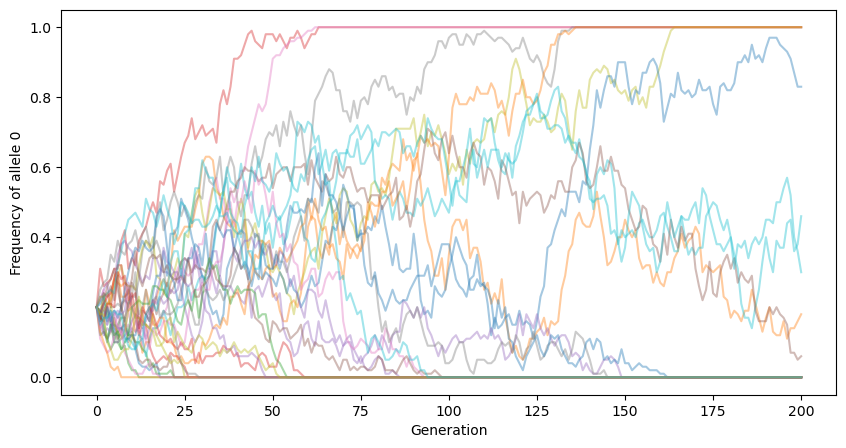

In [110]:
replication_num = 30

def wright_fisher_modeling_by_replicas(diploid_n, p0, T, rep_num):
    trajectories = []
    for _ in range(rep_num):
        trajectory = wright_fisher_modeling(diploid_n, p0, T)
        trajectories.append(trajectory)

    return trajectories

trajectories = wright_fisher_modeling_by_replicas(diploid_n, p0, T, replication_num)

pyplot.figure(figsize=(10, 5))
for trajectory in trajectories:
    pyplot.plot(trajectory, alpha=0.4)

pyplot.xlabel('Generation')
pyplot.ylabel('Frequency of allele 0')
pyplot.show()


2) Большая часть реплик полетела в дрейфе в 1 или 0, меньшая часть блуждают, но пропадут при росте T в бесконечность.

Expected heteroz by replicas:  [0.32       0.31564667 0.31140667 0.31167333 0.30755333 0.30622
 0.30802667 0.31304667 0.29238667 0.28853333 0.27918    0.27088667
 0.26024    0.25049333 0.25236667 0.2547     0.24726    0.24924
 0.23864667 0.23606    0.22578667 0.21686    0.21947333 0.21079333
 0.20469333 0.19324667 0.19356    0.18967333 0.18918667 0.18250667
 0.17596    0.17725333 0.17478667 0.17495333 0.17676667 0.17168667
 0.16814    0.16721333 0.1735     0.16516667 0.17706    0.18471333
 0.18424667 0.18846    0.18944667 0.18642    0.17826    0.17434667
 0.16538    0.1637     0.16601333 0.16116667 0.15827333 0.15288
 0.15572667 0.15236667 0.15204    0.14623333 0.14034667 0.14052
 0.13524    0.13617333 0.13642667 0.12586    0.1235     0.11772
 0.11918    0.11944    0.11786    0.11823333 0.11614    0.11848667
 0.11144667 0.11245333 0.10936    0.11494667 0.11094    0.10528667
 0.1058     0.11062667 0.10811333 0.10522    0.10811333 0.10770667
 0.10001333 0.09674    0.0987     0.09990667 0

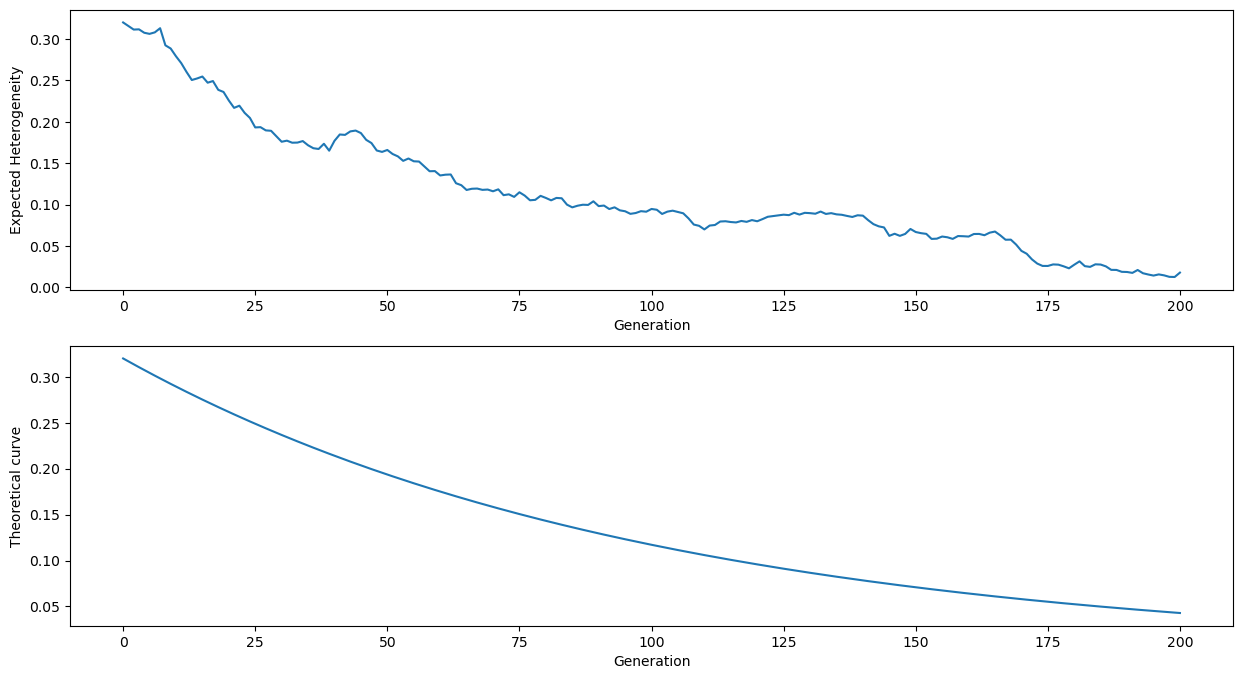

In [94]:
def get_heteroz(trajectories):
    # На входе N реплик, надо посчитать heteroz по каждой реплике
    heteroz = []
    # тут уже p по поколениям
    for p in trajectories:
        heteroz.append(2.0 * p * (1 - p))

    return np.mean(heteroz, axis=0)

# усредняем по репликам
heteroz_between_replications = get_heteroz(trajectories)

print("Expected heteroz by replicas: ", heteroz_between_replications)

H0 = heteroz_between_replications[0]
teoretical_curve = H0 * np.pow((1.0  - 1.0 / (2 * diploid_n)), np.arange(T + 1))

pyplot.figure(figsize=(15, 8))
pyplot.subplot(211)

pyplot.plot(heteroz_between_replications)
pyplot.xlabel("Generation")
pyplot.ylabel("Expected Heterogeneity")

pyplot.subplot(212)
pyplot.plot(teoretical_curve)
pyplot.xlabel("Generation")
pyplot.ylabel("Theoretical curve")

pyplot.show()


3) Видно, что число ожидаемой гетерозиготности падает с ростом поколения (особенно видно по теоретической кривой ожидания).

In [ ]:
def get_absorbed_count(trajectories_np):
    # Берем последнее поколение
    return np.sum(trajectories_np[:, -1] == 0) + np.sum(trajectories_np[:, -1] == 1)

trajectories_np = np.array(trajectories)
absorbed_count = get_absorbed_count(trajectories_np)

print(f"Number of replicas: {trajectories_np.shape[0]},  Absorbed: {absorbed_count}")

Number of replicas: 30,  Absorbed: 27


4) Теорема о полглощении точно работает, потому что:

 - В модели WF без мутаций каждая траектория обязательно достигнет 0 или 1 за конечное время (это и есть "поглощение")
 - упала почти до 0 средняя гетерозиготность (вероятность обратиться в 0 у некоторых реплик абсолютная)
 - с ростом поколений вообще падает гетерозиготность и есть поглощение (вверх или вниз - 1 или 0), блуждающих реплик всё меньше, с еще большим ростом их станет ноль (пруф будет ниже)
 - при p0 = 0.2, p1 = 0.8 цифры на прогоне из ноутбука такие: 

In [72]:
# Взял квадрат Times
trajectories_np = np.array(wright_fisher_modeling_by_replicas(diploid_n, p0, T * T, replication_num))

print(f"Number of replicas: {trajectories_np.shape[0]},  Absorbed: {get_absorbed_count(trajectories_np)}")


Number of replicas: 30,  Absorbed: 30


In [92]:
# Добавляем бутылочное горлышко с кол-вом диполей n_bottleneck на диапазоне times_bottleneck
def wright_fisher_modeling_bottleneck(diploid_n, n_bottleneck, p0, times=100, times_bottleneck=[100, 125]):
    p_curr = p0
    # аллелей в 2 раза больше
    N = 2 * diploid_n
    N_bottleneck = n_bottleneck * 2
    result_seq = np.array(p0)
    for i in range(times):
        if times_bottleneck[0] <= i + 1 <= times_bottleneck[1]:
            p_curr = binomial(N_bottleneck, p_curr) / N_bottleneck
        else:
            p_curr = binomial(N, p_curr) / N

        result_seq = np.append(result_seq, p_curr)

    return result_seq

def wright_fisher_modeling_with_bottleneck_by_replicas(diploid_n, n_bottleneck, p0, T, rep_num):
    trajectories = []
    for _ in range(rep_num):
        trajectory = wright_fisher_modeling_bottleneck(diploid_n, n_bottleneck, p0, T)
        trajectories.append(trajectory)

    return trajectories

diploid_n_bottleneck = 10

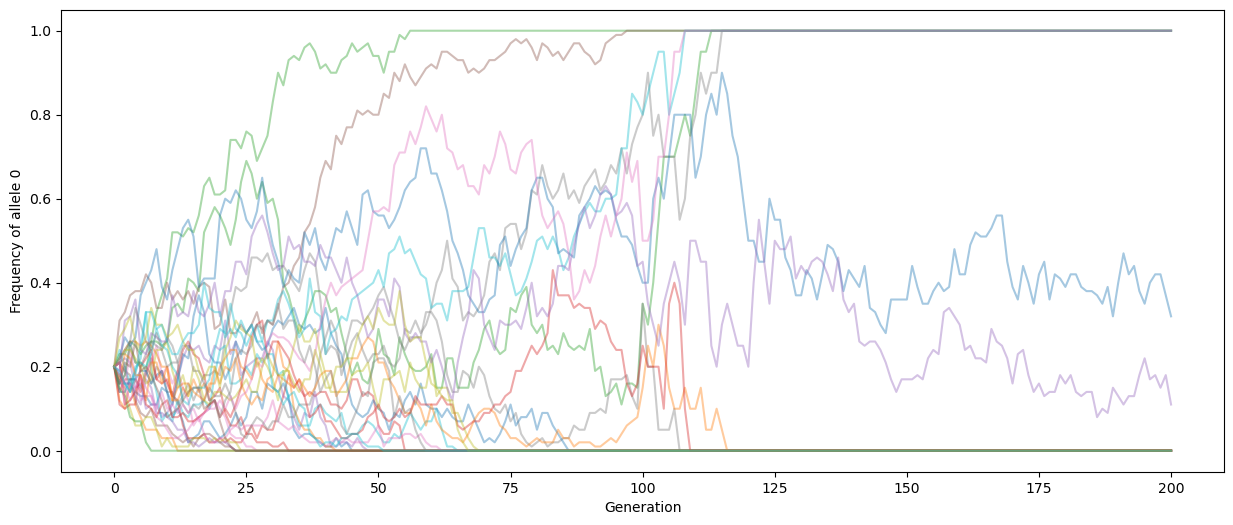

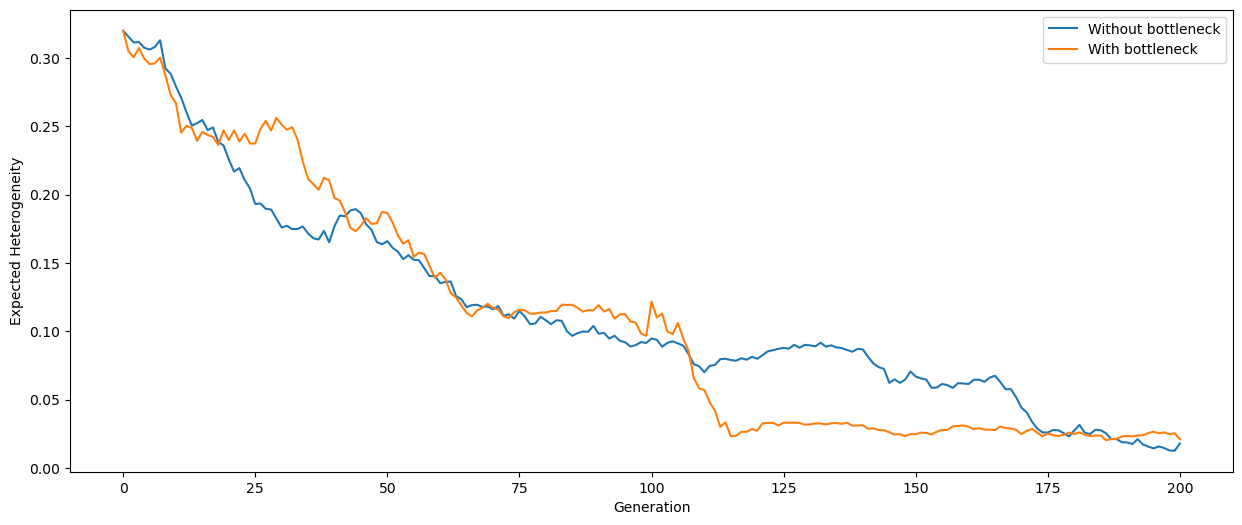

In [105]:
trajectories_bottleneck = wright_fisher_modeling_with_bottleneck_by_replicas(diploid_n, diploid_n_bottleneck,  p0, T, replication_num)

pyplot.figure(figsize=(15, 6))
for trajectory in trajectories_bottleneck:
    pyplot.plot(trajectory, alpha=0.4)

pyplot.xlabel('Generation')
pyplot.ylabel('Frequency of allele 0')
pyplot.show()

# усредняем по репликам
heteroz_between_replications_bottleneck = get_heteroz(trajectories_bottleneck)

pyplot.figure(figsize=(15, 6))
pyplot.plot(heteroz_between_replications, label='Without bottleneck')
pyplot.plot(heteroz_between_replications_bottleneck, label='With bottleneck')

pyplot.xlabel("Generation")
pyplot.ylabel("Expected Heterogeneity")
pyplot.legend()
pyplot.show()


5) Бутылочное горлышко

- Видно, что на диапазоне 100...125 резко вырождаются много дорожек (кластеров). Это как раз и есть эффект бутылочного горлышка.

- Также на графиках ожидаемой гетерозиготности можно просиледить: она более остро падает на диапазоне 100...125 в версии с горлышком, так как треды вырождаются в гомозиготность.